generate synthetic data by using the beginning token from the training data for a model

run the model autoregressively, try a few different temperatures T for sampling

In [1]:
%load_ext autoreload

In [2]:
%autoreload 2
import os
import numpy as np
import torch
import torch.nn.functional as F
# import webdataset as wds
from tqdm.auto import tqdm
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

from umt.evals.eval_utils import load_model_from_checkpoint

/scratch/gpfs/WBIALEK/ls1546/.conda/envs/gpt-circuits/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The code length of a sequence $x_1, \dots, x_T$ under the model is
$$\ell(x) = -\sum_{t=1}^{T} \log_2 p(x_t \mid x_1, \dots, x_{t-1})$$
where $p$ is the model's softmax distribution at temperature $T{=}1$.

**Pass 1 — generation.** We sample each token from the temperature-adjusted distribution
$q_T(x_t \mid \cdot) \propto p(x_t \mid \cdot)^{1/T}$. Temperature controls diversity,
not the model's actual beliefs.

**Pass 2 — evaluation.** We feed the completed sequence back through the model
(forward pass with targets) to obtain the *true* log-probabilities $\log p(x_t \mid \cdot)$
and compute $\ell(x)$.

At $T{=}1$ the expected per-token code length equals the model's entropy.
At $T{<}1$ (deterministic) code lengths should be *lower*; at $T{>}1$ (random) they
should be *higher*. Comparing against real-text genres tells us which temperature
regime each genre lives in.


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neox-20b", use_fast=True)

Device: cuda


In [4]:
# --- paths ---
base_dir = '/scratch/gpfs/WBIALEK/ls1546/llms-entropy'
data_base = '/scratch/gpfs/WBIALEK/ls1546/DCLM/rust_processing/tokshuf-rs'
ckpt_base = os.path.join('/scratch/gpfs/WBIALEK/ls1546/gpt-circuits', 'out')
save_dir = os.path.join(base_dir, 'synth_data')
fig_dir = os.path.join(base_dir, 'figures')
os.makedirs(save_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# --- model arch (matches training configs) ---
n_layer = 24
n_head = 16
n_embd = 2048
block_size = 2048
bias = False
dropout = 0.0
z_loss = 1e-4

# --- eval settings ---
eval_shard = 1          
batch_size = 2          # sequences per forward pass (tune to fit GPU memory)
max_sequences = 1    # None = all sequences in the shard; set to small int for quick tests

In [6]:
def load_model(run_name, ckpt_num):
    ckpt_path = os.path.join(ckpt_base, run_name, f'{run_name}_ckpt_{ckpt_num}.pt')
    checkpoint = torch.load(ckpt_path, map_location=device)
    model = load_model_from_checkpoint(
        checkpoint, n_layer, n_head, n_embd, block_size, bias, dropout, z_loss, device
    )
    model.eval()
    return model

does autoregressive generation match the codelength results from actual data?

test on 1 token from training data (shard 1)

compute codelength as function of context length, sample at different T and plot all on same figure

also plot some histograms of the distribution at each position

In [7]:
test_run = 'shard1_m1337_d1337'
test_ckpt = 47000

model = load_model(test_run, test_ckpt)
print(f"Loaded {test_run} ckpt {test_ckpt}")

number of parameters: 1713.78M
Loaded shard1_m1337_d1337 ckpt 47000


### compute code length on generated sequences

Feed the generated token IDs back through the model as a standard forward pass
(with targets) to get the true log-probabilities at each position.


In [10]:
@torch.no_grad()
def calc_codelength_from_ids(model, token_ids, batch_size=4):
    """
    Compute per-position code lengths for pre-tokenized sequences.

    Args:
        model:     GPT model in eval mode
        token_ids: (N, seq_len) numpy array or tensor of token ids
        batch_size: forward-pass batch size

    Returns:
        avg_codelen:   scalar, average code length in bits/token
        pos_avg:       (seq_len-1,) numpy array, per-position average code length
        all_codelen:   (N, seq_len-1) numpy array, per-token code lengths
    """
    if isinstance(token_ids, np.ndarray):
        token_ids = torch.from_numpy(token_ids).long()

    N, S = token_ids.shape
    pos_sum = torch.zeros(S - 1)
    pos_count = torch.zeros(S - 1)
    all_codelen = []

    for start in tqdm(range(0, N, batch_size), desc="codelength eval"):
        ids = token_ids[start : start + batch_size].to(device)  # (B, S)
        inp = ids[:, :-1].contiguous()       # (B, S-1)
        tgt = ids[:, 1:].contiguous()        # (B, S-1)

        logits, _ = model(inp, tgt)          # (B, S-1, V)
        log_probs = F.log_softmax(logits, dim=-1)  # numerically stable

        # gather the log-prob assigned to each actual next token
        token_log_probs = log_probs.gather(-1, tgt.unsqueeze(-1)).squeeze(-1)  # (B, S-1)
        codelen = -token_log_probs / np.log(2)  # nats -> bits

        all_codelen.append(codelen.cpu())
        T = codelen.shape[1]
        pos_sum[:T] += codelen.sum(dim=0).cpu()
        pos_count[:T] += codelen.shape[0]

    all_codelen = torch.cat(all_codelen, dim=0).numpy()  # (N, S-1)
    pos_avg = (pos_sum / pos_count.clamp_min(1)).numpy()
    avg_codelen = all_codelen.mean()

    return avg_codelen, pos_avg, all_codelen


### Inspect: decode a few generated sequences at each temperature

In [12]:
n_examples = 2
max_chars = 500

for T in temperatures:
    id_path = os.path.join(save_dir, f'synth_ids_T{T}.npy')
    if not os.path.exists(id_path):
        print(f'T={T}: {id_path} not found, skipping')
        continue

    synth_ids = np.load(id_path)
    print(f"\nT={T}: loaded {synth_ids.shape} from disk")
    print(f"\n{'='*60}")
    print(f"T = {T}")
    print(f"{'='*60}")
    for i in range(min(n_examples, synth_ids.shape[0])):
        text = tokenizer.decode(synth_ids[i])
        print(f"\n--- Sequence {i} ---")
        print(text[:max_chars])
        print('...')



T=0.5: loaded (10000, 2048) from disk

T = 0.5

--- Sequence 0 ---
 loans, you may be able to keep your home.

Read More: Can You Keep Your Home When You Quit Your Job?

If you have a mortgage that is in foreclosure, the bank may be able to buy your house.

This is an option if you can’t afford to pay the mortgage on your own.

You might be able to keep your home if you can’t find a lender willing to work with you.

You may need to pay a lot more for this option than you would if you were able to keep your house.

The bank will likely want to see that you are a
...

--- Sequence 1 ---
 used to be the only way to get the money in the first place.

The other thing that makes me want to move away from the Bay Area is the lack of public transportation. I've been driving to work for the past 10 years, and I've never been happier. I've never had to worry about my car breaking down, or running out of gas. I don't have to worry about parking, because I live in a place where it's easily access

### Pass 2: load precomputed code lengths

Run on the cluster (one GPU job per temperature):

```bash
cd /scratch/gpfs/WBIALEK/ls1546/llms-entropy
sbatch --array=0 slurmfiles/calc_synth_codelen.slurm   # pilot: T=0.5 only
sbatch slurmfiles/calc_synth_codelen.slurm             # all 5 temperatures

python3 calc_synth_codelen.py status --data-dir synth_data
```

Writes `synth_data/synth_codelen_T{T}.npz` with keys `pos_avg`, `all_codelen`, `avg_codelen`.


In [5]:
temperatures = [0.5, 0.8, 1.0, 1.2, 1.5]

results = {}

for T in temperatures:
    npz_path = os.path.join(save_dir, f'synth_codelen_T{T}.npz')
    id_path = os.path.join(save_dir, f'synth_ids_T{T}.npy')

    if not os.path.exists(npz_path):
        print(f'T={T}: {npz_path} not found — run calc_synth_codelen.py on the cluster')
        continue

    with np.load(npz_path) as d:
        pos_avg = d['pos_avg']
        all_cl = d['all_codelen']
        avg_cl = float(d['avg_codelen']) if 'avg_codelen' in d else float(all_cl.mean())

    print(f"\nT={T}: loaded codelengths {all_cl.shape} from {npz_path}")
    print(f"  Avg code length: {avg_cl:.4f} bits/token")

    results[T] = {
        'avg_codelen': avg_cl,
        'pos_avg': pos_avg,
        'all_codelen': all_cl,
    }

    # mmap token ids only if needed later (e.g. decode examples)
    if os.path.exists(id_path):
        results[T]['synth_ids'] = np.load(id_path, mmap_mode='r')



T=0.5: loaded codelengths (10000, 2047) from /scratch/gpfs/WBIALEK/ls1546/llms-entropy/synth_data/synth_codelen_T0.5.npz
  Avg code length: 0.2344 bits/token

T=0.8: loaded codelengths (10000, 2047) from /scratch/gpfs/WBIALEK/ls1546/llms-entropy/synth_data/synth_codelen_T0.8.npz
  Avg code length: 1.9395 bits/token

T=1.0: loaded codelengths (10000, 2047) from /scratch/gpfs/WBIALEK/ls1546/llms-entropy/synth_data/synth_codelen_T1.0.npz
  Avg code length: 5.5928 bits/token

T=1.2: loaded codelengths (10000, 2047) from /scratch/gpfs/WBIALEK/ls1546/llms-entropy/synth_data/synth_codelen_T1.2.npz
  Avg code length: 12.9475 bits/token

T=1.5: loaded codelengths (10000, 2047) from /scratch/gpfs/WBIALEK/ls1546/llms-entropy/synth_data/synth_codelen_T1.5.npz
  Avg code length: 14.8822 bits/token


### Plot: code length vs position for each temperature


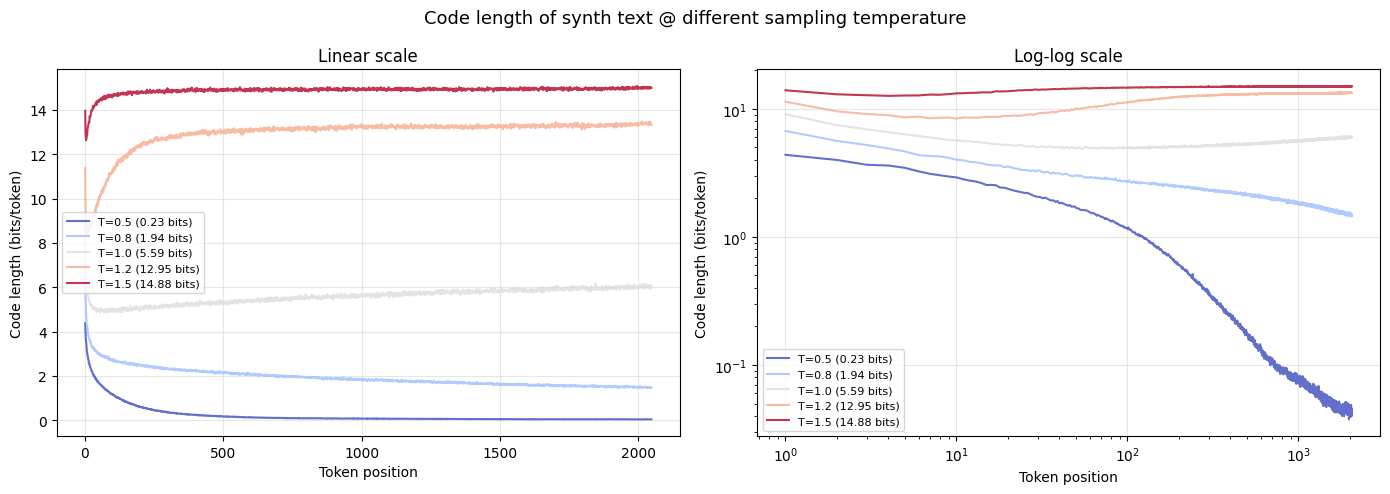

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cmap = plt.cm.coolwarm
T_vals = sorted(results.keys())
norm = plt.Normalize(vmin=min(T_vals), vmax=max(T_vals))

for T in T_vals:
    pos_avg = results[T]['pos_avg']
    positions = np.arange(1, len(pos_avg) + 1)
    color = cmap(norm(T))
    label = f'T={T} ({results[T]["avg_codelen"]:.2f} bits)'

    axes[0].plot(positions, pos_avg, color=color, alpha=0.8, label=label)
    axes[1].plot(positions, pos_avg, color=color, alpha=0.8, label=label)

axes[0].set_xlabel('Token position')
axes[0].set_ylabel('Code length (bits/token)')
axes[0].set_title('Linear scale')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Token position')
axes[1].set_ylabel('Code length (bits/token)')
axes[1].set_title('Log-log scale')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Code length of synth text @ different sampling temperature', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, 'synth_codelen_vs_temperature.pdf'), bbox_inches='tight')
plt.show()


### Summary: average code length at each temperature


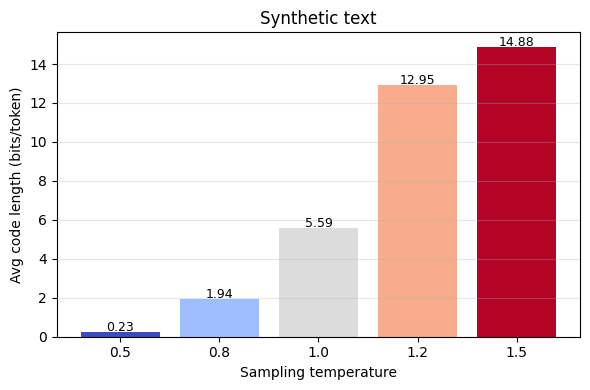

In [21]:
T_vals = sorted(results.keys())
avg_cls = [results[T]['avg_codelen'] for T in T_vals]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([str(T) for T in T_vals], avg_cls, color=[cmap(norm(T)) for T in T_vals])
ax.set_xlabel('Sampling temperature')
ax.set_ylabel('Avg code length (bits/token)')
ax.set_title('Synthetic text')
for bar, val in zip(bars, avg_cls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontsize=9)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, 'synth_avg_codelen_bar.pdf'), bbox_inches='tight')
plt.show()


### Histograms: per-token code length distributions at selected positions


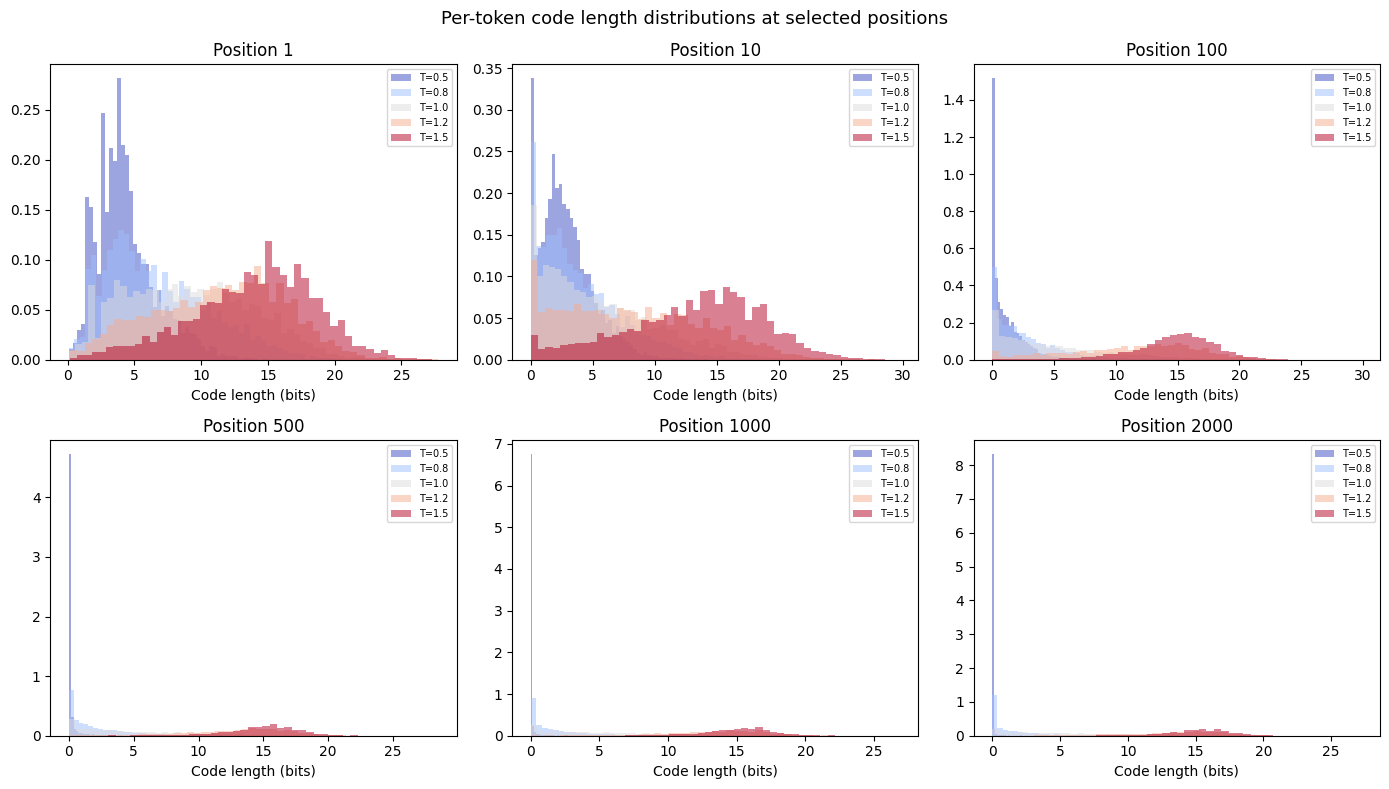

In [22]:
positions_to_plot = [1, 10, 100, 500, 1000, 2000]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, pos in zip(axes, positions_to_plot):
    idx = pos - 1  # 0-indexed into (N, S-1) codelength array
    for T in sorted(results.keys()):
        cl = results[T]['all_codelen']
        if idx < cl.shape[1]:
            ax.hist(cl[:, idx], bins=50, alpha=0.5, density=True,
                    color=cmap(norm(T)), label=f'T={T}')
    ax.set_title(f'Position {pos}')
    ax.set_xlabel('Code length (bits)')
    ax.legend(fontsize=7)

fig.suptitle('Per-token code length distributions at selected positions', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, 'synth_codelen_histograms.pdf'), bbox_inches='tight')
plt.show()


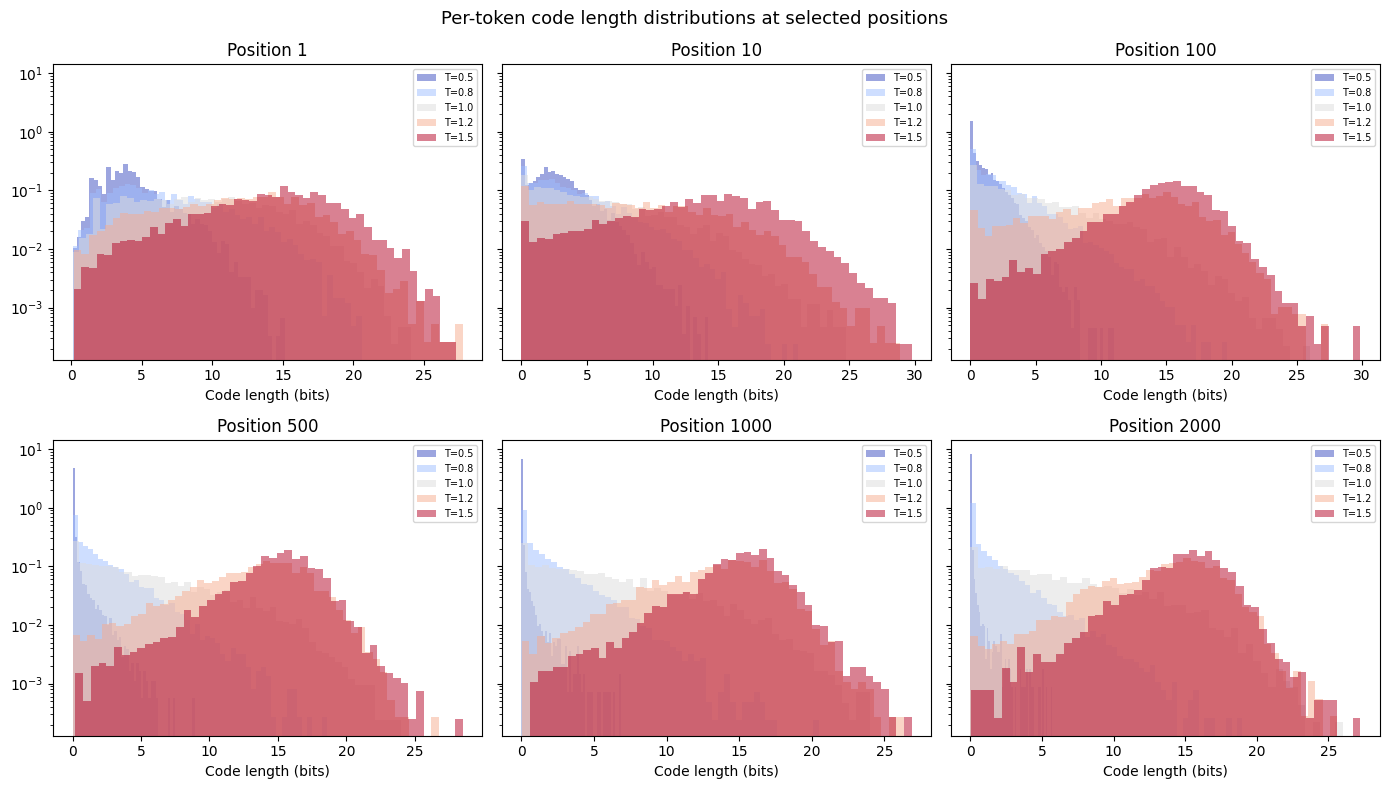

In [23]:
# plot same plot but with log scale on y-axis and same y axis
positions_to_plot = [1, 10, 100, 500, 1000, 2000]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
axes = axes.ravel()

for ax, pos in zip(axes, positions_to_plot):
    idx = pos - 1  # 0-indexed into (N, S-1) codelength array
    for T in sorted(results.keys()):
        cl = results[T]['all_codelen']
        if idx < cl.shape[1]:
            ax.hist(cl[:, idx], bins=50, alpha=0.5, density=True,
                    color=cmap(norm(T)), label=f'T={T}')
    ax.set_title(f'Position {pos}')
    ax.set_xlabel('Code length (bits)')
    ax.set_yscale('log')
    ax.legend(fontsize=7)

fig.suptitle('Per-token code length distributions at selected positions', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, 'synth_codelen_histograms_logscale.pdf'), bbox_inches='tight')
plt.show()


code length for actual symbols -> energy, so variance of code length -> heat capacity. Can get the total energy by adding up the conditional code lengths along the string of N tokens, so we get E(N). See with other analyses that variance of E(N)/N eventually stops decreasing at larger N, maybe even plateaus. That means that the specific heat C = var[E(N)]/N is diverging almost linearly with N.

calculate the heat capacity. see if it peaks at T=1. 

In [6]:
# E(N) = cumulative conditional code length (energy) over the first N tokens
# C(N) = Var_seq[E(N)] / N  (specific heat)

heat_capacity = {}
for T in sorted(results.keys()):
    all_cl = results[T]['all_codelen']          # (n_seq, n_pos)
    E_N = np.cumsum(all_cl, axis=1)             # (n_seq, n_pos)
    Ns = np.arange(1, all_cl.shape[1] + 1)
    var_E = np.var(E_N, axis=0, ddof=0)
    C = var_E / Ns
    heat_capacity[T] = {'Ns': Ns, 'E_N': E_N, 'var_E': var_E, 'C': C}

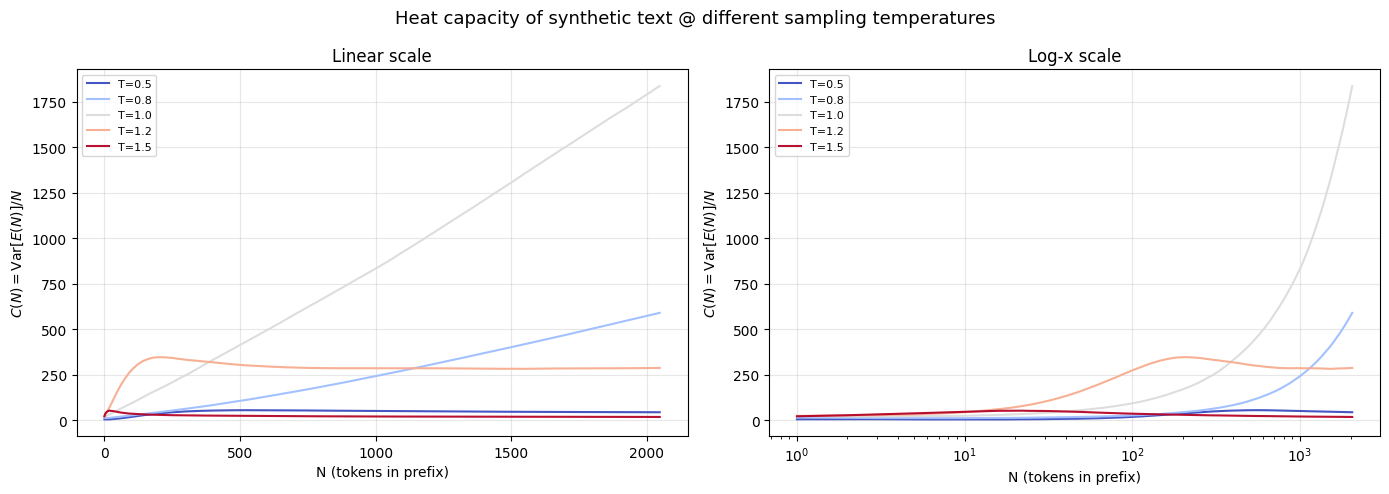

In [14]:
cmap = plt.cm.coolwarm
T_vals = sorted(results.keys())
norm = plt.Normalize(vmin=min(T_vals), vmax=max(T_vals))
# --- Plot: C(N) vs prefix length for each temperature ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

T_vals = sorted(heat_capacity.keys())
for T in T_vals:
    Ns = heat_capacity[T]['Ns']
    C = heat_capacity[T]['C']
    color = cmap(norm(T))
    label = f'T={T}'
    axes[0].plot(Ns, C, color=color, alpha=0.95, label=label)
    axes[1].plot(Ns, C, color=color, alpha=0.95, label=label)

axes[0].set_xlabel('N (tokens in prefix)')
axes[0].set_ylabel(r'$C(N) = \mathrm{Var}[E(N)] / N$')
axes[0].set_title('Linear scale')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('N (tokens in prefix)')
axes[1].set_ylabel(r'$C(N) = \mathrm{Var}[E(N)] / N$')
axes[1].set_title('Log-x scale')
axes[1].set_xscale('log')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Heat capacity of synthetic text @ different sampling temperatures', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, 'synth_heat_capacity_vs_N.pdf'), bbox_inches='tight')
plt.show()

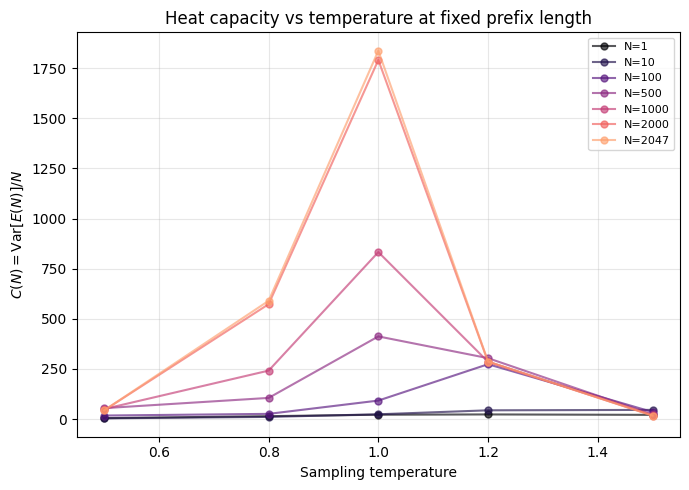

In [24]:
cmap = plt.cm.magma
colors = cmap(np.linspace(0, 0.8, len(N_checkpoints)))
# --- Plot: C(N) vs sampling temperature at selected prefix lengths ---
N_checkpoints = [1, 10, 100, 500, 1000, 2000, 2047]
fig, ax = plt.subplots(figsize=(7, 5))

for i, N in enumerate(N_checkpoints):
    idx = N - 1
    C_at_N = [heat_capacity[T]['C'][idx] for T in T_vals]
    ax.plot(T_vals, C_at_N, 'o-', linewidth=1.5, markersize=5, label=f'N={N}', color=colors[i], alpha=0.65)

ax.set_xlabel('Sampling temperature')
ax.set_ylabel(r'$C(N) = \mathrm{Var}[E(N)] / N$')
ax.set_title('Heat capacity vs temperature at fixed prefix length')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, 'synth_heat_capacity_vs_temperature.pdf'), bbox_inches='tight')
plt.show()